# Impacto do fundo de imagens na classificação

* Construir um sistema que substitui o fundo de uma imagem usando o modelo YOLO. O YOLO detecta a máscara do objeto e copia o objeto para uma outra imagem
* O código abaixo possui funções para realizar a tarefa. ORGANIZAR o código para que seja possível utilizar de forma genérica em diferentes categorias de objetos
* Usar os dados fornecidos abaixo, que possuem 8 categorias de objetos e 12 fundos distintos para analisar a viabilidade do sistema. Por exemplo, identificar todas as images nas quais o modelo não detecta corretamente os objetos. Essas imagens podem ser descartadas para o próximo passo
* Para cada combinação de categoria de objeto e fundo, verificar a alteração na probabilidade média do modelo de classificação convnextv2_tiny

O objeto precisa ocupar ao menos 50% da nova imagem

Imagens de objetos e fundos:

https://www.dropbox.com/scl/fi/kbn9i72ijmoxszio0auon/images.zip?rlkey=6vbhazy80ml3v3tocimsk4d2b&dl=1

Definições de nomes e classes

In [1]:
# Nomes das categorias no ImageNet
imagenet_names = ["banana", "cellular telephone", "computer keyboard", "cup", "dining table",
                  "laptop", "microwave", "orange"]
# Nomes das categorias no modelo YOLO, na mesma ordem das classes do ImageNet
yoloy_names = ["banana", "cell phone", "keyboard", "cup", "dining table",
              "laptop", "microwave", "orange"]

# Lista de categorias de fundo
backgrounds = [
    "indoor/bedroom", "indoor/dining_room", "indoor/kitchen", "indoor/living_room",
    "outdoor_man/crosswalk", "outdoor_man/downtown", "outdoor_man/parking_lot", 
    "outdoor_man/street", "outdoor_nature/corn_field", "outdoor_nature/forest_path", 
    "outdoor_nature/rainforest", "outdoor_nature/wheat_field"
]

# Carrega as classes do ImageNet, como mostrado nos notebooks da disciplina
classes = open("imagenet_classes.txt").read().splitlines()

Exemplo de aquisição da máscara contendo todos os objetos de uma categoria

/home/chcomin/miniconda3/envs/projetos_pdi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



0: 640x640 3 oranges, 3.7ms
Speed: 1.5ms preprocess, 3.7ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 640)


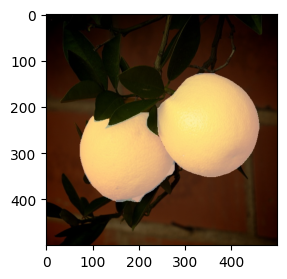

In [2]:
import matplotlib.pyplot as plt
import utils
from PIL import Image
from ultralytics import YOLO

model = YOLO("yolo26n-seg.pt")

img = Image.open("ILSVRC2012_val_00012107.JPEG")

# Detecta o objeto e retorna uma máscara binária
mask = utils.detect(img, model, "orange")

plt.imshow(img)
plt.imshow(mask, "gray", alpha=0.5)

Inserção do objeto em outra imagem

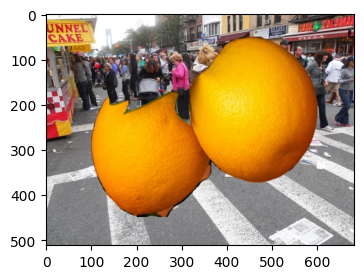

In [3]:
background = Image.open("Places365_val_00001259.jpg")

# Corta o objeto da imagem original usando a máscara
obj_img, obj_mask = utils.crop(img, mask)
# Cola o objeto recortado sobre a imagem de fundo
mixed_img = utils.paste(
    background, 
    obj_img, 
    obj_mask, 
    obj_size=(500, 400), # (largura, altura) do objeto
    obj_pos=(100, 50)   # (coluna, linha) do canto superior esquerdo do objeto na imagem
    )

plt.imshow(mixed_img)

Classificação da imagem usando uma rede neural

In [4]:
model, transforms = utils.load_model("convnextv2_tiny")

In [5]:
for img in [img, mixed_img]:
    probs = utils.apply_model(img, model, transforms)
    results = utils.build_results(probs, classes, "orange")

    print(results)

{'true_class': ('orange', 0.879883885383606), 'predicted_class': ('orange', 0.879883885383606), 'second_predicted': ('lemon', 0.03377185016870499)}
{'true_class': ('orange', 0.8257520794868469), 'predicted_class': ('orange', 0.8257520794868469), 'second_predicted': ('lemon', 0.02519647218286991)}
